# Before / After Analysis

这个 notebook 会：

1. 读取 `result.xlsx`
2. 按每个 `*_before` 和 `*_after` 配对
3. 计算每个 `ICxxxx` 在每个特征上的 `after - before`
4. 统计每个特征差值的 `mean` 和 `std`
5. 画出带误差条的图
6. 把结果保存成 `csv/png/xlsx`


In [1]:
from pathlib import Path
import os
import re
import sys

def find_base_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / 'data' / 'before_after_0-300',
        Path('/Users/lijiajun/Desktop/imperial/SWEG/nlp_grant_coursework/data/before_after_0-300'),
    ]
    for candidate in candidates:
        if (candidate / 'result.xlsx').exists():
            return candidate.resolve()
    raise FileNotFoundError('Cannot find result.xlsx. Please place this notebook in the same folder as result.xlsx or run it from the repo root.')

BASE_DIR = find_base_dir()

# Fallback for openpyxl in this workspace.
bundled_site_packages = Path('/Users/lijiajun/.cache/codex-runtimes/codex-primary-runtime/dependencies/python/lib/python3.12/site-packages')
if bundled_site_packages.exists() and str(bundled_site_packages) not in sys.path:
    sys.path.append(str(bundled_site_packages))

# Make matplotlib cache writable in notebook environments.
mpl_dir = BASE_DIR / '.mplconfig'
mpl_dir.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(mpl_dir))
os.environ.setdefault('XDG_CACHE_HOME', str(BASE_DIR / '.cache'))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import openpyxl  # noqa: F401
except ImportError as exc:
    raise ImportError('openpyxl is required to read/write xlsx files in this notebook.') from exc

INPUT_XLSX = BASE_DIR / 'result.xlsx'
PAIRWISE_CSV = BASE_DIR / 'pairwise_differences.csv'
STATS_CSV = BASE_DIR / 'feature_stats.csv'
PLOT_PNG = BASE_DIR / 'before_after_feature_delta.png'
OUTPUT_XLSX = BASE_DIR / 'before_after_analysis_output.xlsx'

print('BASE_DIR =', BASE_DIR)
print('INPUT_XLSX =', INPUT_XLSX)


BASE_DIR = /Users/lijiajun/Desktop/imperial/SWEG/nlp_grant_coursework/data/before_after_0-300
INPUT_XLSX = /Users/lijiajun/Desktop/imperial/SWEG/nlp_grant_coursework/data/before_after_0-300/result.xlsx


In [2]:
def parse_signal_average(value):
    if pd.isna(value):
        return None
    match = re.search(r'[-+]?\d*\.?\d+', str(value))
    return float(match.group()) if match else None

df = pd.read_excel(INPUT_XLSX)
id_col = df.columns[0]
score_columns = list(df.columns[1:])
preferred_order = [
    'Final score',
    'Signal average',
    'Application Form',
    'General',
    'Proposed Research',
    'Sites & Support',
    'Training & Development',
    'Working with People & Communities',
]
score_columns = [col for col in preferred_order if col in score_columns] + [col for col in score_columns if col not in preferred_order]

df = df.rename(columns={id_col: 'record_id'}).copy()
if 'Signal average' in df.columns:
    df['Signal average'] = df['Signal average'].apply(parse_signal_average)

parts = df['record_id'].astype(str).str.extract(r'^(?P<sample_id>.+)_(?P<phase>before|after)$')
if parts.isna().any().any():
    bad_ids = df.loc[parts.isna().any(axis=1), 'record_id'].tolist()
    raise ValueError(f'这些 ID 无法识别 before/after: {bad_ids}')

df['sample_id'] = parts['sample_id']
df['phase'] = parts['phase']

display(df.head())
print('rows =', len(df))
print('sample count =', df['sample_id'].nunique())
print('score columns =', score_columns)


,record_id,Final score,Signal average,Application Form,General,Proposed Research,Sites & Support,Training & Development,Working with People & Communities,sample_id,phase
0,IC00011_before,83.5,4.3,76.7,87.7,90.0,90.0,80.0,76.7,IC00011,before
1,IC00011_after,88.3,4.4,89.4,90.0,97.5,97.5,80.0,75.5,IC00011,after
2,NIHR503119_before,37.7,1.9,73.3,15.0,63.5,17.5,0.0,56.7,NIHR503119,before
3,NIHR503119_after,84.4,4.2,91.1,82.7,89.4,81.2,73.3,88.9,NIHR503119,after
4,IC00047_before,81.0,4.1,80.0,94.0,89.4,72.5,93.3,56.7,IC00047,before


rows = 36
sample count = 18
score columns = ['Final score', 'Signal average', 'Application Form', 'General', 'Proposed Research', 'Sites & Support', 'Training & Development', 'Working with People & Communities']


In [3]:
before_df = df[df['phase'] == 'before'][['sample_id', *score_columns]].set_index('sample_id').sort_index()
after_df = df[df['phase'] == 'after'][['sample_id', *score_columns]].set_index('sample_id').sort_index()

missing_before = sorted(set(after_df.index) - set(before_df.index))
missing_after = sorted(set(before_df.index) - set(after_df.index))
if missing_before or missing_after:
    raise ValueError(f'配对不完整。missing_before={missing_before}, missing_after={missing_after}')

# Difference is defined as after - before.
pairwise_diff = after_df.subtract(before_df)
pairwise_diff.insert(0, 'sample_id', pairwise_diff.index)
pairwise_diff = pairwise_diff.reset_index(drop=True)

display(pairwise_diff)
print('difference definition = after - before')

check_columns = ['Final score', 'Signal average']
available_check_columns = [col for col in check_columns if col in score_columns]
audit_table = before_df[available_check_columns].add_prefix('before_').join(
    after_df[available_check_columns].add_prefix('after_')
)
for col in available_check_columns:
    audit_table[f'diff_{col}'] = after_df[col] - before_df[col]
display(audit_table.head())


,sample_id,Final score,Signal average,Application Form,General,Proposed Research,Sites & Support,Training & Development,Working with People & Communities
0,IC00011,4.8,0.1,12.7,2.3,7.5,7.5,0.0,-1.2
1,IC00047,11.0,0.5,9.4,5.0,8.1,16.3,-1.6,28.9
2,IC00065,6.4,0.1,5.0,-1.7,12.1,-20.0,0.0,1.1
3,IC00093,22.9,1.0,-2.2,56.7,10.6,7.5,0.0,42.2
4,IC00106,-4.0,-0.2,4.4,-6.0,5.4,7.5,-20.0,-15.5
5,IC00114,2.0,0.1,0.0,2.0,2.5,0.0,-1.6,8.9
6,IC00128,5.4,0.5,-4.4,6.0,36.1,-20.0,-6.7,21.1
7,IC00137,6.7,0.1,30.0,-18.9,22.5,-7.5,-56.7,21.1
8,IC00220,0.3,0.0,0.0,0.0,2.1,0.0,0.0,0.0
9,IC00312,11.1,-0.3,-1.6,-6.1,21.7,0.0,0.0,8.9


difference definition = after - before


,before_Final score,before_Signal average,after_Final score,after_Signal average,diff_Final score,diff_Signal average
sample_id,,,,,,
IC00011,83.5,4.3,88.3,4.4,4.8,0.1
IC00047,81.0,4.1,92.0,4.6,11.0,0.5
IC00065,35.8,1.8,42.2,1.9,6.4,0.1
IC00093,49.4,2.1,72.3,3.1,22.9,1.0
IC00106,88.8,4.5,84.8,4.3,-4.0,-0.2


In [4]:
feature_stats = (
    pairwise_diff[score_columns]
    .agg(['mean', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': 'feature'})
)
feature_stats.insert(1, 'count', len(pairwise_diff))
feature_stats['feature'] = pd.Categorical(feature_stats['feature'], categories=score_columns, ordered=True)
feature_stats = feature_stats.sort_values('feature').reset_index(drop=True)
feature_stats['feature'] = feature_stats['feature'].astype(str)

display(feature_stats)


,feature,count,mean,std,min,max
0,Final score,18,7.827778,18.920167,-42.5,46.7
1,Signal average,18,0.283333,0.946977,-2.3,2.3
2,Application Form,18,3.983333,12.991004,-33.3,30.0
3,General,18,6.594444,33.364378,-82.3,67.7
4,Proposed Research,18,9.233333,15.939444,-31.2,36.1
5,Sites & Support,18,4.522222,29.311563,-75.0,63.7
6,Training & Development,18,3.516667,30.762817,-56.7,85.0
7,Working with People & Communities,18,10.366667,18.815576,-33.3,42.2


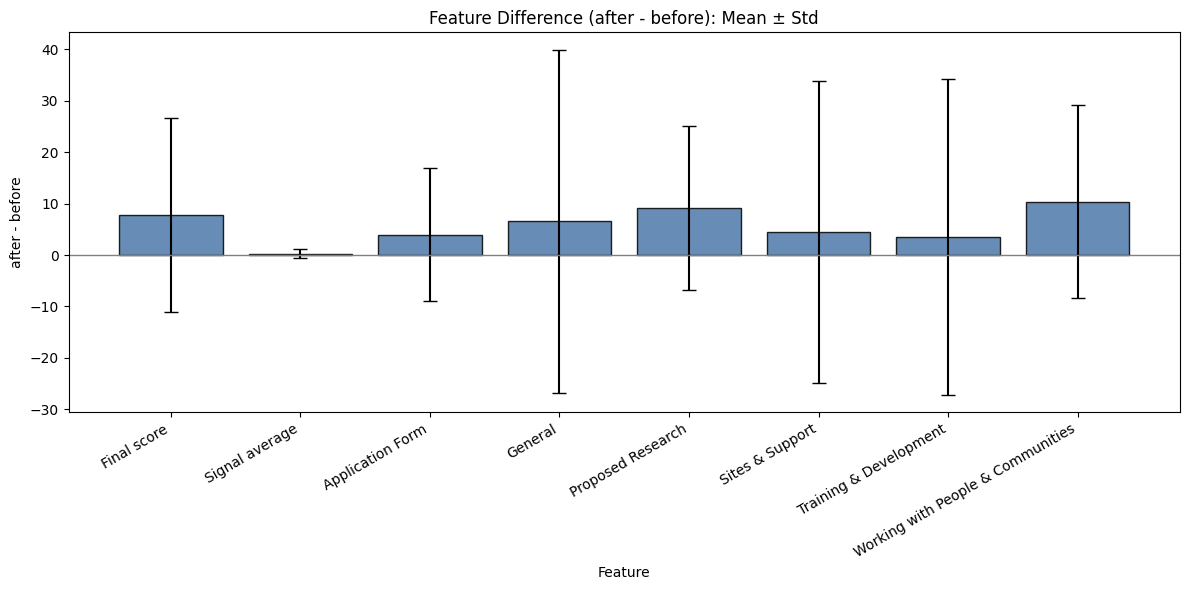

In [5]:
plot_df = feature_stats.copy()
plt.figure(figsize=(12, 6))
x = range(len(plot_df))

plt.bar(
    x,
    plot_df['mean'],
    yerr=plot_df['std'],
    capsize=5,
    color='#4C78A8',
    edgecolor='black',
    alpha=0.85,
)

plt.axhline(0, color='gray', linewidth=1)
plt.xticks(list(x), plot_df['feature'], rotation=30, ha='right')
plt.ylabel('after - before')
plt.xlabel('Feature')
plt.title('Feature Difference (after - before): Mean ± Std')
plt.tight_layout()
plt.show()
